# Player Archetype EDA

**Project Objective**:

Gather football player and team data to create a player scouting dashboard,
which utilises data analyses and Machine Learning to identify player architects,
and lesser-known players that may fit these.


**Plan**:
1. Data Prep
      - Import data and create a data dictionary
      - Check data quality (data types, missingness, duplicates)
2. EDA
      - Qualitative EDA (counts & distributions)
      - Quantitative EDA
        - Descriptive exploration (distribution, uniqueness)
        - Skew & Kurtosis
        - Outliers
        - Relationships & Redundant Columns (correlation, heirarchical clustering)
        - Check scaling
      - Combined EDA (check for relationships between Qualitative and Quantitative data)

See `project-plan.md` and `data-dictionary.md` in `/docs` for more detail.

## Setup & Imports

In [284]:
import pandas as pd
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from statsmodels.graphics.mosaicplot import mosaic

from scripts.column_group_exploration import explore_column_group
from scripts.outlier_exploration import explore_outliers
from scripts.dimensionality_reduction import explore_dimensionality_reduction

sns.set_theme(style="whitegrid")

# Constants
SEASON = '21-22'

## Pre-processing

In [285]:
raw_player_data = pd.read_csv('../data/raw/2021-2022 Football Player Stats.csv', sep=';', encoding='latin1')
raw_player_data = raw_player_data.copy()
# raw_player_data['season'] = SEASON

invalid_character_count = raw_player_data.Player.str.contains('\\?', na=True, regex=True).sum()

if invalid_character_count > 0:
    print(f"WARNING: {invalid_character_count} `Player` values have a '?' in them.")

raw_player_data.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Max Aarons,ENG,DF,Norwich City,Premier League,22.0,2000,34,32,...,0.03,1.41,1.16,0.0,0.06,0.03,5.53,0.47,1.59,22.7
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,34.0,1987,34,34,...,0.00,0.06,1.39,0.0,0.03,0.00,6.77,2.02,1.36,59.8
2,3,Salis Abdul Samed,GHA,MF,Clermont Foot,Ligue 1,22.0,2000,31,29,...,0.00,0.36,1.24,0.0,0.00,0.00,8.76,0.88,0.88,50.0
3,4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,29.0,1993,34,34,...,0.03,0.79,2.23,0.0,0.00,0.00,8.87,0.43,0.43,50.0
4,5,Charles Abi,FRA,FW,Saint-Étienne,Ligue 1,22.0,2000,1,1,...,0.00,2.00,0.00,0.0,0.00,0.00,4.00,2.00,0.00,100.0


Some `Player` values have a question mark as a character. These are present in the underlying .csv; these will be left for the MVP, but an alternative data source for Phase2 may not have these.

There are very few metrics relevant to goalkeepers, and the requirements of the position are significantly different to outfield, making a single approach accross both groups inappropriate. Goalkeepers will therefore be excluded from this stage of the project. Goalkeeper-specific metrics may be available elsewhere, enabling a dedicated goalkeeper model & analysis to be produced at a later date.

Players with under 600 minutes at any given club will be excluded, to prevent skewing the data.

In [286]:
# Rk is just an index column (sorted by last name). Names also include special characters, which will require normalisation
player_data = raw_player_data.drop('Rk', axis=1)
player_data['Player'] = player_data['Player'].apply(unidecode)

# Remove goalkeepers
player_data = player_data[~player_data.Pos.str.contains("GK")]

# Require a minimum of 600 minutes
player_data = player_data[player_data.Min >= 600]

duplicate_player_count = player_data.duplicated(subset="Player").sum()
duplicates_found = duplicate_player_count > 0

if duplicates_found:
    print(f"{duplicate_player_count} duplicate Player names found.")
    duplicate_players = player_data[player_data.duplicated(subset='Player', keep=False)].sort_values(by='Player')
    display(duplicate_players.head(10))
else:
    print("No duplicates found")

26 duplicate Player names found.


,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
1096,Bruno Guimaraes,BRA,MF,Lyon,Ligue 1,24.0,1997,20,19,1634,...,0.05,0.93,2.47,0.05,0.0,0.0,7.53,0.71,0.82,46.4
1097,Bruno Guimaraes,BRA,MF,Newcastle Utd,Premier League,24.0,1997,17,11,1034,...,0.35,0.78,3.39,0.00,0.0,0.0,10.50,0.52,1.04,33.3
2859,Chris Wood,NZL,FW,Burnley,Premier League,30.0,1991,17,17,1367,...,1.05,0.33,0.53,0.00,0.0,0.0,2.70,7.50,6.91,52.1
2858,Chris Wood,NZL,FW,Newcastle Utd,Premier League,30.0,1991,17,15,1327,...,0.68,0.14,0.20,0.07,0.0,0.0,3.47,9.93,8.71,53.3
398,Dan Burn,ENG,DF,Brighton,Premier League,30.0,1992,13,12,1022,...,0.00,0.09,1.32,0.00,0.0,0.0,8.77,3.60,1.75,67.2
399,Dan Burn,ENG,DF,Newcastle Utd,Premier League,30.0,1992,16,16,1440,...,0.31,0.06,0.75,0.00,0.0,0.0,10.80,5.63,1.75,76.3
1446,Dejan Kulusevski,SWE,FWMF,Juventus,Serie A,22.0,2000,20,5,772,...,0.35,1.28,1.28,0.00,0.0,0.0,7.21,1.28,2.56,33.3
1445,Dejan Kulusevski,SWE,MFFW,Tottenham,Premier League,22.0,2000,18,14,1261,...,0.29,1.71,1.14,0.00,0.0,0.0,6.43,0.36,0.93,27.8
2801,Duan Vlahovi?,SRB,FW,Fiorentina,Serie A,22.0,2000,21,21,1857,...,0.92,0.87,0.15,0.00,0.0,0.0,3.01,2.18,2.48,46.9
2800,Duan Vlahovi?,SRB,FW,Juventus,Serie A,22.0,2000,15,12,1076,...,1.00,0.50,0.17,0.00,0.0,0.0,3.58,1.58,2.83,35.8


Players are duplicated when they have played for two clubs in a season.

**Options:**
1. Aggregate the metrics
2. Select only one entry (either the first or last club played-for, or the most-played for)
3. Treat both entries as separate
4. Some combination of these, accounting for league played in (e.g. aggregate if in the same league, else keep separate or select one)

**Decision:** _As we only have access to limited (one or two seasons worth of) data, we will aggregate the entries to avoid as much information loss as possible._

### Pre-Aggregation EDA on Duplicate Player Data

Before aggregating, we need to perform a quick sanity check. If a player appears twice, do their core attributes (e.g. `Nation`, `Age`, `Born`) also change?

`Nation` should rarely change (although it is possible that a player could change their declared nation).
`Age` could increment by 1, depending on how it is calculated (e.g. if it is calculated at the start of the season or at the moment of the row split).
`Born` should never change, and if so will indicate either a mistake or that they are two players with a common name.
It is unclear how `Pos` is currently calculated, or if it can change.

We will check for any variations in `Nation`, `Pos`, `Age`, and `Born` for players with multiple entries.

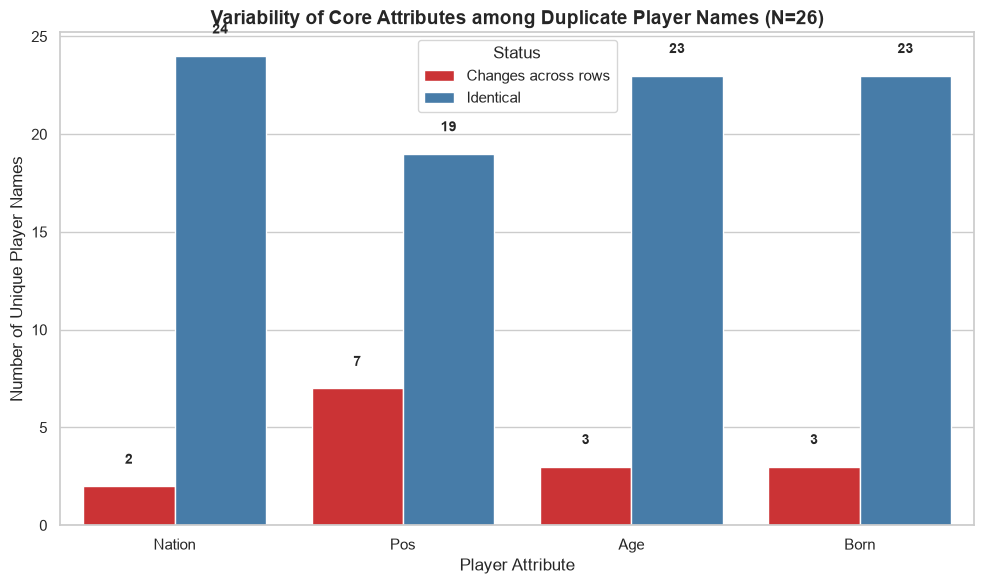

In [287]:
if duplicates_found:
    unique_counts = duplicate_players.groupby('Player')[['Nation', 'Pos', 'Age', 'Born']].nunique()

    changes = (unique_counts > 1).sum().reset_index()
    changes.columns = ['Attribute', 'Players_With_Changes']
    changes['Players_With_No_Changes'] = unique_counts.shape[0] - changes['Players_With_Changes']

    melted = changes.melt(id_vars='Attribute', var_name='Status', value_name='Count')
    melted['Status'] = melted['Status'].replace({
        'Players_With_Changes': 'Changes across rows',
        'Players_With_No_Changes': 'Identical'
    })

    plt.figure(figsize=(10, 6))
    sns.set_theme(style='whitegrid')
    ax = sns.barplot(data=melted, x='Attribute', y='Count', hue='Status', palette='Set1')
    plt.title(f'Variability of Core Attributes among Duplicate Player Names (N={duplicate_player_count})', fontsize=14, fontweight='bold')
    plt.xlabel('Player Attribute', fontsize=12)
    plt.ylabel('Number of Unique Player Names', fontsize=12)
    plt.legend(title='Status')

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

3 Players have different Born values, suggesting these may actually be two different players with a common name.
The same is true for Age, although these are likely the same players.

In [288]:
# find Players with multiple Born values
if duplicates_found:
    born_counts = duplicate_players.groupby('Player')['Born'].nunique()
    born_collision_players = born_counts[born_counts > 1].index

    born_collisions = duplicate_players[duplicate_players['Player'].isin(born_collision_players)].sort_values(by=['Player', 'Born'])

    display(born_collisions[['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born']])

,Player,Nation,Pos,Squad,Comp,Age,Born
2066,Joao Pedro,ITA,FW,Cagliari,Serie A,30.0,1992
2067,Joao Pedro,BRA,FWMF,Watford,Premier League,20.0,2001
1036,Nicolas Gonzalez,ARG,FW,Fiorentina,Serie A,24.0,1998
1035,Nicolas Gonzalez,ESP,MF,Barcelona,La Liga,20.0,2002
2284,Rodrigo,ESP,MFFW,Leeds United,Premier League,31.0,1991
2285,Rodrigo,ESP,FW,Betis,La Liga,22.0,2000


In [289]:
# find Players with different Ages, to check if they are the same
if duplicates_found:
    age_counts = duplicate_players.groupby('Player')['Age'].nunique()
    age_collision_players = age_counts[age_counts > 1].index

    age_collisions = duplicate_players[duplicate_players['Player'].isin(age_collision_players)].sort_values(by=['Player', 'Born'])

    if age_collisions.equals(born_collisions):
        print("The 'Born' overlaps are the same players as the 'Age' overlaps")

The 'Born' overlaps are the same players as the 'Age' overlaps


In [290]:
# Check the nationality overlaps
if duplicates_found:
    nation_counts = duplicate_players.groupby('Player')['Nation'].nunique()
    nation_collision_players = nation_counts[nation_counts > 1].index

    nation_collisions = duplicate_players[duplicate_players['Player'].isin(nation_collision_players)].sort_values(by=['Player', 'Born'])

    display(nation_collisions[['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born']])

,Player,Nation,Pos,Squad,Comp,Age,Born
2066,Joao Pedro,ITA,FW,Cagliari,Serie A,30.0,1992
2067,Joao Pedro,BRA,FWMF,Watford,Premier League,20.0,2001
1036,Nicolas Gonzalez,ARG,FW,Fiorentina,Serie A,24.0,1998
1035,Nicolas Gonzalez,ESP,MF,Barcelona,La Liga,20.0,2002


It is clear that the overlaps in Born, Age, and Nation are all due to different players sharing a common name. An identifying column can be made by combining these colums.

In [291]:
# add to the player_data dataframe as processing, and to duplicate_players for further pre-aggregating EDA

player_data['player_identifier'] = (
        player_data['Player'] + '_' + player_data['Nation'] + '_' + player_data['Born'].astype(str))

duplicate_players['player_identifier'] = (
        duplicate_players['Player'] + '_' + duplicate_players['Nation'] + '_' + duplicate_players['Born'].astype(str))


player_data[['Player', 'Nation', 'Age', 'Born', 'player_identifier']]

,Player,Nation,Age,Born,player_identifier
0,Max Aarons,ENG,22.0,2000,Max Aarons_ENG_2000
1,Yunis Abdelhamid,MAR,34.0,1987,Yunis Abdelhamid_MAR_1987
2,Salis Abdul Samed,GHA,22.0,2000,Salis Abdul Samed_GHA_2000
3,Laurent Abergel,FRA,29.0,1993,Laurent Abergel_FRA_1993
5,Dickson Abiama,NGA,23.0,1998,Dickson Abiama_NGA_1998
...,...,...,...,...,...
2916,Martin Zubimendi,ESP,23.0,1999,Martin Zubimendi_ESP_1999
2917,Szymon ?urkowski,POL,24.0,1997,Szymon ?urkowski_POL_1997
2918,Martin Odegaard,NOR,23.0,1998,Martin Odegaard_NOR_1998
2919,Milan ?uri?,BIH,32.0,1990,Milan ?uri?_BIH_1990


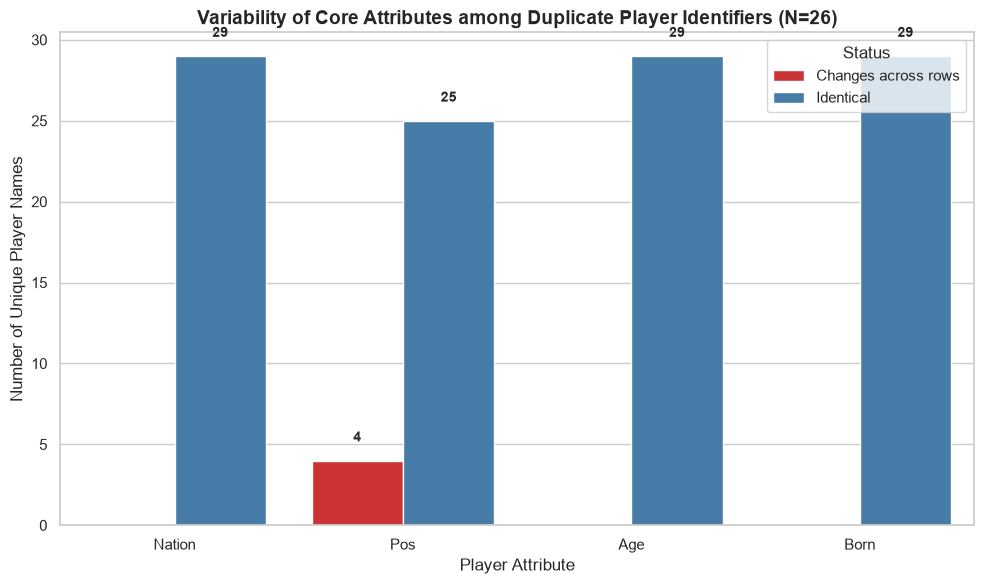

In [292]:
# Rerunning pre-aggregation checks using this new identifier:
if duplicates_found:
    unique_counts = duplicate_players.groupby('player_identifier')[['Nation', 'Pos', 'Age', 'Born']].nunique()

    changes = (unique_counts > 1).sum().reset_index()
    changes.columns = ['Attribute', 'Players_With_Changes']
    changes['Players_With_No_Changes'] = unique_counts.shape[0] - changes['Players_With_Changes']

    melted = changes.melt(id_vars='Attribute', var_name='Status', value_name='Count')
    melted['Status'] = melted['Status'].replace({
        'Players_With_Changes': 'Changes across rows',
        'Players_With_No_Changes': 'Identical'
    })

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=melted, x='Attribute', y='Count', hue='Status', palette='Set1')
    plt.title(f'Variability of Core Attributes among Duplicate Player Identifiers (N={duplicate_player_count})', fontsize=14, fontweight='bold')
    plt.xlabel('Player Attribute', fontsize=12)
    plt.ylabel('Number of Unique Player Names', fontsize=12)
    plt.legend(title='Status')

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

These has removed the majority of the crossovers, however there are still a  small number (4) of duplicate players with multiple positions.

In [293]:
# find Players with multiple Pos values
if duplicates_found:
    pos_counts = duplicate_players.groupby('player_identifier')['Pos'].nunique()
    pos_collision_players = pos_counts[pos_counts > 1].index

    pos_collisions = duplicate_players[duplicate_players['player_identifier'].isin(pos_collision_players)].sort_values(by=['player_identifier', 'Born'])

    display(pos_collisions[['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'player_identifier']])

,Player,Nation,Pos,Squad,Comp,Age,Born,player_identifier
1446,Dejan Kulusevski,SWE,FWMF,Juventus,Serie A,22.0,2000,Dejan Kulusevski_SWE_2000
1445,Dejan Kulusevski,SWE,MFFW,Tottenham,Premier League,22.0,2000,Dejan Kulusevski_SWE_2000
1231,Jonathan Ikone,FRA,FW,Fiorentina,Serie A,24.0,1998,Jonathan Ikone_FRA_1998
1230,Jonathan Ikone,FRA,MFFW,Lille,Ligue 1,24.0,1998,Jonathan Ikone_FRA_1998
2097,Lucas Perez,ESP,FW,Elche,La Liga,33.0,1988,Lucas Perez_ESP_1988
2098,Lucas Perez,ESP,FWMF,Cádiz,La Liga,33.0,1988,Lucas Perez_ESP_1988
849,Romain Faivre,FRA,FWMF,Lyon,Ligue 1,23.0,1998,Romain Faivre_FRA_1998
848,Romain Faivre,FRA,MF,Brest,Ligue 1,23.0,1998,Romain Faivre_FRA_1998


This is due to players playing a different set of positions at different clubs. This leaves 5 options:
1. Treat the entries as distinct, as different positions are likely to have different metric profiles (will lead to multiple rows for some players, overweighting them in modelling)
2. Track all the positions played across the season, however this could lead to skewed data (as different positions will naturally lead to different performance metrics, but will be collapsed)
3. Remove the players entirely from the dataset (may skew the data as high-performers may be more likely to transfer)
4. Acquire more granular position data (ideal, but outside the scope of the MVP for this project)

For the MVP, and as the player's `Pos` values are already aggregated across the dataset (i.e. players can already have multiple positions), tracking all the positions played is justified. However, acquiring more granular detail will be an important discovery step for Phase 2.

---

The final major consideration for aggregating multi-row players is how to handle multiple `Comp` and `Club` values. While these won't be included as part of the player architecture modelling, they are very likely to be relevant to player value prediction. One-hot-encoding will be required for modelling anyway, but Comp can instead be transformed to a `{Comp Name}_pct_mins`, taking the percentage of the player's minute played in each of the 5 leagues included in the dataset. In order to scale this to more leagues for future modelling, during Phase2 `Comp` can instead be replaced by some measure of league-level coefficient (e.g. UEFA coefficient for European clubs), with a weighted average being taken according to the `pct_mins` a player played in each league.

`Club` cannot be simply one-hot-encoded, as cardinality will be too high. For the MVP, club will be excluded as a modelling feature and array aggregated for post-modelling analyis only. For Phase2 club-level metrics (e.g. ELO, league finish, etc) can be used instead.


### Aggregation

**Decisions:**
| Consideration | MVP Solution | Phase2 Improvement |
| ------------- | ------------ | ------------------ |
| `Pos` | Combine positions played across the season, and weighted-average (by minutes) the stats. One-hot-encode for modelling. | Acquire granular position level data (e.g. minutes player per position, or stats split by position player) |
| `Comp` | Create a column for each league, showing the percentage of minutes played in each. Exclude from clustering. | Replace Comp name from feature set with league-level data, such as coefficients. |
| `Club` | Array aggregate (as with `Pos`), but exclude from all modelling. | As with `Comp`, replace Club names with club-level metrics (ELO, league finish, etc) |

---

As per the data-dictionary.md, the other columns are counts (which can be summed to aggregate), or ratios and percentages. The latter two will need re-calculating to ensure a weighted-average. The majority of these can be recalculated from existing (summed) columns, however three cannot:
- Min% (Playing Time): Requires total team minutes which is not present in the dataset.
- On-Off (Playing Time): Requires team-level off-pitch performance stats.
- Dist (Shooting): Recalculating a true average shot distance requires individual shot distances or total shot counts/distances which are not available.

The aggregation strategy for these will be:
- Min%: Drop the column
- On-Off: Drop the column
- Dist: take a weighted average based on number of shots. e.g. (dist_at_clubA * shots_at_clubA + dist_at_clubB * shots_at_clubB)/(shots_at_clubA + shots_at_clubB)

In [294]:
# Aggregate to one row per player based on the strategy above:

player_data_clean = player_data.copy()

# estimate a weighted shot distance column
player_data_clean['ShoDist_weighted'] = player_data_clean['ShoDist'] * player_data_clean['Shots']

# split minutes played into one for each league
comps = player_data_clean['Comp'].dropna().unique()
comp_min_cols = []
for comp in comps:
    min_col = f"{comp}_pct_mins"
    player_data_clean[min_col] = player_data_clean['Min'].where(player_data_clean['Comp'] == comp, 0)
    comp_min_cols.append(min_col)

# define the aggregation strategy in a dictionary
agg_dict = {}

numeric_cols = player_data_clean.select_dtypes(include='number').columns
recalc_cols = ['90s', 'SoT%', 'G/Sh', 'G/SoT', 'PasTotCmp%', 'PasShoCmp%', 'PasMedCmp%', 'PasLonCmp%', 'TklDri%', 'Press%', 'DriSucc%', 'Rec%', 'AerWon%', 'ShoDist']
exclude_from_sum = recalc_cols + ['Age', 'Born']

agg_dict['Player'] = 'first'
agg_dict['Nation'] = 'first'
agg_dict['Born'] = 'first'
agg_dict['Age'] = 'max'
agg_dict['Pos'] = lambda x: ''.join(sorted(x.unique()))
agg_dict['Squad'] = lambda x: ', '.join(sorted(x.unique()))
agg_dict['Comp'] = lambda x: ', '.join(sorted(x.unique()))

for col in numeric_cols:
    if col not in exclude_from_sum:
        agg_dict[col] = 'sum'

# aggregate using the dictionary
aggregated_player_data = player_data_clean.groupby('player_identifier').agg(agg_dict)

# determine the primary position (first position listed in the row with maximum minutes)
idx_max_min = player_data_clean.groupby('player_identifier')['Min'].idxmax()
primary_pos_map = player_data_clean.loc[idx_max_min].set_index('player_identifier')['Pos'].str[:2]
aggregated_player_data['Primary_Pos'] = aggregated_player_data.index.map(primary_pos_map)

# convert the league minutes column to a percentage of minutes played
for pct_col in comp_min_cols:
    aggregated_player_data[pct_col] = (aggregated_player_data[pct_col] / aggregated_player_data['Min']).fillna(0)

# Recalculate ratios and percentages
aggregated_player_data['90s'] = aggregated_player_data['Min'] / 90
aggregated_player_data['SoT%'] = (aggregated_player_data['SoT'] / aggregated_player_data['Shots'] * 100).fillna(0)
aggregated_player_data['G/Sh'] = (aggregated_player_data['Goals'] / aggregated_player_data['Shots']).fillna(0)
aggregated_player_data['G/SoT'] = (aggregated_player_data['Goals'] / aggregated_player_data['SoT']).fillna(0)
aggregated_player_data['PasTotCmp%'] = (aggregated_player_data['PasTotCmp'] / aggregated_player_data['PasTotAtt'] * 100).fillna(0)
aggregated_player_data['PasShoCmp%'] = (aggregated_player_data['PasShoCmp'] / aggregated_player_data['PasShoAtt'] * 100).fillna(0)
aggregated_player_data['PasMedCmp%'] = (aggregated_player_data['PasMedCmp'] / aggregated_player_data['PasMedAtt'] * 100).fillna(0)
aggregated_player_data['PasLonCmp%'] = (aggregated_player_data['PasLonCmp'] / aggregated_player_data['PasLonAtt'] * 100).fillna(0)
aggregated_player_data['TklDri%'] = (aggregated_player_data['TklDri'] / aggregated_player_data['TklDriAtt'] * 100).fillna(0)
aggregated_player_data['Press%'] = (aggregated_player_data['PresSucc'] / aggregated_player_data['Press'] * 100).fillna(0)
aggregated_player_data['DriSucc%'] = (aggregated_player_data['DriSucc'] / aggregated_player_data['DriAtt'] * 100).fillna(0)
aggregated_player_data['Rec%'] = (aggregated_player_data['Rec'] / aggregated_player_data['RecTarg'] * 100).fillna(0)
aggregated_player_data['AerWon%'] = (aggregated_player_data['AerWon'] / (aggregated_player_data['AerWon'] + aggregated_player_data['AerLost']) * 100).fillna(0)
aggregated_player_data['ShoDist'] = (aggregated_player_data['ShoDist_weighted'] / aggregated_player_data['Shots']).fillna(0)

# create the estimate for weighted average shot distance
aggregated_player_data = aggregated_player_data.drop(columns=['ShoDist_weighted'])
aggregated_player_data = aggregated_player_data.replace([np.inf, -np.inf], 0)

aggregated_player_data = aggregated_player_data.reset_index().copy()

print(f"Original shape: {player_data.shape}")
print(f"Aggregated shape: {aggregated_player_data.shape}")

Original shape: (1760, 143)
Aggregated shape: (1737, 149)


/var/folders/z2/nnyy1mcn66g48lv04812439r0000gp/T/ipykernel_36018/3784359281.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aggregated_player_data['Primary_Pos'] = aggregated_player_data.index.map(primary_pos_map)
/var/folders/z2/nnyy1mcn66g48lv04812439r0000gp/T/ipykernel_36018/3784359281.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aggregated_player_data['90s'] = aggregated_player_data['Min'] / 90
/var/folders/z2/nnyy1mcn66g48lv04812439r0000gp/T/ipykernel_36018/3784359281.py:49: PerformanceWarning: DataFrame is hig

In [295]:
if duplicates_found:
    display(aggregated_player_data[aggregated_player_data.player_identifier.isin(duplicate_players.player_identifier)].head(10))
else:
    display(aggregated_player_data.head(10))

,player_identifier,Player,Nation,Born,Age,Pos,Squad,Comp,MP,Starts,...,PasTotCmp%,PasShoCmp%,PasMedCmp%,PasLonCmp%,TklDri%,Press%,DriSucc%,Rec%,AerWon%,ShoDist
223,Bruno Guimaraes_BRA_1997,Bruno Guimaraes,BRA,1997,24.0,MF,"Lyon, Newcastle Utd","Ligue 1, Premier League",37,30,...,86.773378,92.110874,89.934354,76.725746,39.698492,30.688259,52.286282,92.373608,39.805825,19.475697
264,Chris Wood_NZL_1991,Chris Wood,NZL,1991,30.0,FW,"Burnley, Newcastle Utd",Premier League,34,32,...,57.482185,62.996109,53.946147,61.352657,49.253731,28.461538,44.776119,50.471204,52.738275,11.440000
300,Dan Burn_ENG_1992,Dan Burn,ENG,1992,30.0,DF,"Brighton, Newcastle Utd",Premier League,29,28,...,80.994475,83.261803,88.053097,65.761148,44.206009,35.233645,37.500000,96.159317,72.505892,8.408462
351,Dejan Kulusevski_SWE_2000,Dejan Kulusevski,SWE,2000,22.0,FWMFMFFW,"Juventus, Tottenham","Premier League, Serie A",38,19,...,82.276423,86.227545,87.881773,69.030733,34.733894,26.247423,47.619048,72.621810,31.968811,15.935949
394,Duan Vlahovi?_SRB_2000,Duan Vlahovi?,SRB,2000,22.0,FW,"Fiorentina, Juventus",Serie A,36,33,...,69.072165,73.459988,69.541139,69.203540,14.925373,30.699261,46.325879,56.782334,41.455347,14.985211
742,Jeremie Boga_CIV_1997,Jeremie Boga,CIV,1997,25.0,FWMF,"Atalanta, Sassuolo",Serie A,27,15,...,81.084198,86.770428,83.991770,57.894737,29.651163,30.220307,55.884586,83.348499,34.433962,18.376667
767,Joao Pedro_BRA_2001,Joao Pedro,BRA,2001,20.0,FWMF,Watford,Premier League,28,15,...,68.888889,72.500000,70.613563,66.237113,25.287356,32.065217,52.052239,67.045455,36.490850,15.600000
768,Joao Pedro_ITA_1992,Joao Pedro,ITA,1992,30.0,FW,Cagliari,Serie A,37,37,...,71.356784,78.439153,74.404015,65.614035,34.146341,24.198473,49.431818,54.814815,37.067545,14.300000
796,Jonathan Ikone_FRA_1998,Jonathan Ikone,FRA,1998,24.0,FWMFFW,"Fiorentina, Lille","Ligue 1, Serie A",35,20,...,81.081081,85.185185,85.573770,73.096447,34.220532,30.250000,56.445557,80.947255,37.647059,17.508824
835,Josuha Guilavogui_FRA_1990,Josuha Guilavogui,FRA,1990,31.0,MFDF,"Bordeaux, Wolfsburg","Bundesliga, Ligue 1",30,25,...,82.386364,87.500000,85.434783,71.351879,42.408377,36.549521,60.317460,94.821208,74.491180,17.601460


In [296]:
remaining_dupes = aggregated_player_data[aggregated_player_data.player_identifier.isin(duplicate_players.player_identifier)]
duplicate_player_count = remaining_dupes.duplicated(subset="player_identifier").sum()

print(f"{duplicate_player_count} duplicate players remaining")

0 duplicate players remaining


## Exploratory Analysis

In [297]:
qualitative_columns = list(aggregated_player_data.select_dtypes(include='string').columns)
quantitative_columns = list(aggregated_player_data.select_dtypes(include='number').columns)

### Qualitative Columns (Pos, Nation, Comp, and Squad)

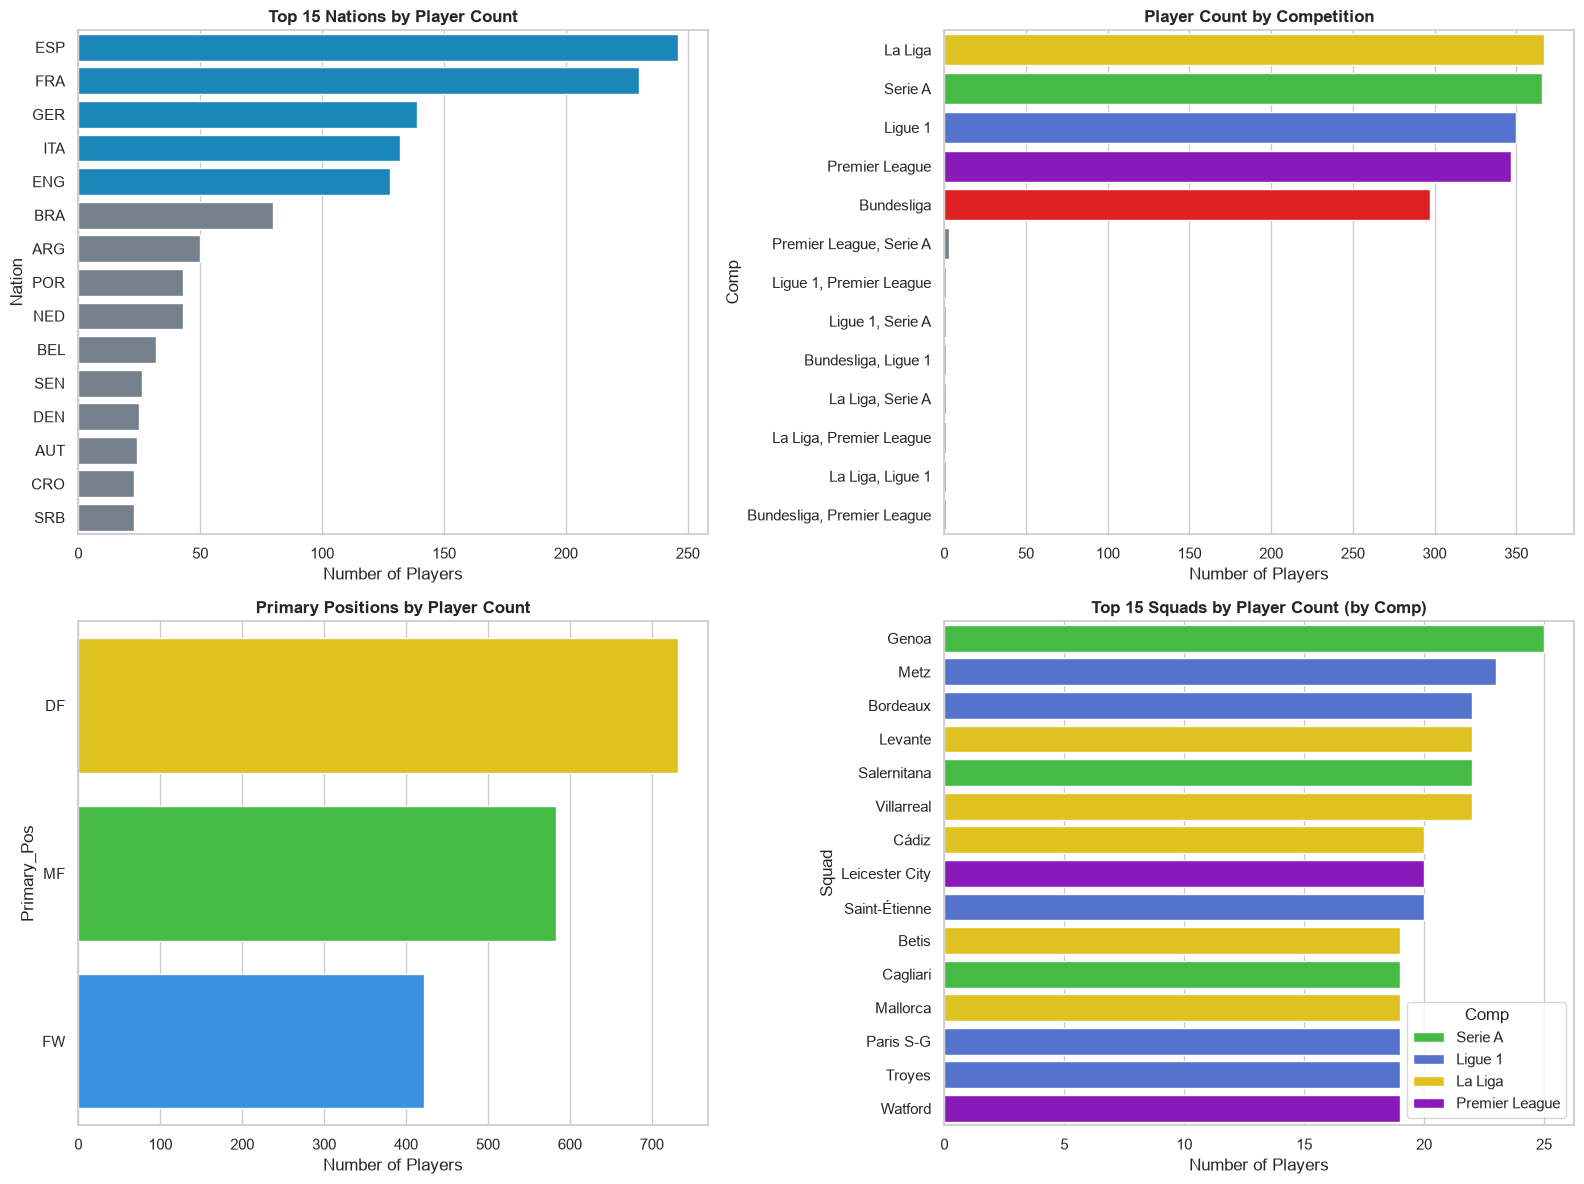

In [298]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Target top 5 nations
target_nations = {"ESP", "FRA", "GER", "ITA", "ENG"}

# ---------------------------------------------------------
# 1. Top 15 Nations by Player Count (Conditional Blue/Red)
# ---------------------------------------------------------
top_nations = aggregated_player_data["Nation"].value_counts().head(15)
nation_colors = {
    nation: "#008fd5" if nation in target_nations else "slategrey"
    for nation in top_nations.index
}

sns.barplot(
    x=top_nations.values,
    y=top_nations.index,
    hue=top_nations.index,
    palette=nation_colors,
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    "Top 15 Nations by Player Count", fontsize=12, fontweight="bold"
)
axes[0, 0].set_xlabel("Number of Players")

# ---------------------------------------------------------
# 2. Player Count by Competition (Custom Palette with Fallback)
# ---------------------------------------------------------
# Define custom colors for competitions (add your specific values here)
comp_palette_map = {
    "Premier League": "darkviolet",
    "La Liga": "gold",
    "Bundesliga": "red",
    "Serie A": "limegreen",
    "Ligue 1": "royalblue",
}

comp_counts = aggregated_player_data["Comp"].value_counts()
comp_colors = {
    comp: comp_palette_map.get(comp, "slategrey") for comp in comp_counts.index
}

sns.barplot(
    x=comp_counts.values,
    y=comp_counts.index,
    hue=comp_counts.index,
    palette=comp_colors,
    ax=axes[0, 1],
)
axes[0, 1].set_title(
    "Player Count by Competition", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Number of Players")

# ---------------------------------------------------------
# 3. Top 10 Positions (Custom Palette with Fallback)
# ---------------------------------------------------------
# Define custom colors for positions (add your specific values here)
pos_palette_map = {
    "DF": "gold",
    "MF": "limegreen",
    "FW": "dodgerblue",
    "GK": "darkorange",

}

top_pos = aggregated_player_data["Primary_Pos"].value_counts().head(10)
pos_colors = {
    pos: pos_palette_map.get(pos, "slategrey") for pos in top_pos.index
}

sns.barplot(
    x=top_pos.values,
    y=top_pos.index,
    hue=top_pos.index,
    palette=pos_colors,
    ax=axes[1, 0],
)
axes[1, 0].set_title(
    "Primary Positions by Player Count", fontsize=12, fontweight="bold"
)
axes[1, 0].set_xlabel("Number of Players")

# ---------------------------------------------------------
# 4. Top 15 Squads Colored by Competition
# ---------------------------------------------------------
top_squad_names = (
    aggregated_player_data["Squad"].value_counts().head(15).index
)

# Filter dataset to top 15 squads and aggregate count per Squad and Comp
top_squads_df = (
    aggregated_player_data[
        aggregated_player_data["Squad"].isin(top_squad_names)
    ]
    .groupby(["Squad", "Comp"])
    .size()
    .reset_index(name="Count")
    .sort_values(by="Count", ascending=False)
)

sns.barplot(
    data=top_squads_df,
    x="Count",
    y="Squad",
    hue="Comp",
    palette=comp_colors,  # Reuses competition color map from Chart 2
    dodge=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title(
    "Top 15 Squads by Player Count (by Comp)", fontsize=12, fontweight="bold"
)
axes[1, 1].set_xlabel("Number of Players")

plt.tight_layout()
plt.show()

In [299]:
categories = {
    "Nation": "Top 5 Nations",
    "Comp": "Top 5 Competitions",
    "Primary_Pos": "Top 5 Positions",
    "Squad": "Top 5 Squads",
}

for col, title in categories.items():
    counts = aggregated_player_data[col].value_counts().head(5)
    total_valid = aggregated_player_data[col].count()

    summary_df = pd.DataFrame(
        {
            col: counts.index,
            "Count": counts.values,
            "Percentage (%)": ((counts.values / total_valid) * 100).round(2),
        }
    )

    print(f"\n{'='*15} {title} {'='*15}")
    print(summary_df.to_string(index=False))


=============== Top 5 Nations ===============
Nation  Count  Percentage (%)
   ESP    246           14.16
   FRA    230           13.24
   GER    139            8.00
   ITA    132            7.60
   ENG    128            7.37

=============== Top 5 Competitions ===============
          Comp  Count  Percentage (%)
       La Liga    367           21.13
       Serie A    366           21.07
       Ligue 1    350           20.15
Premier League    347           19.98
    Bundesliga    297           17.10

=============== Top 5 Positions ===============
Primary_Pos  Count  Percentage (%)
         DF    732           42.14
         MF    583           33.56
         FW    422           24.29

=============== Top 5 Squads ===============
     Squad  Count  Percentage (%)
     Genoa     25            1.44
      Metz     23            1.32
  Bordeaux     22            1.27
Villarreal     22            1.27
   Levante     22            1.27


,player_identifier,Player,Nation,Born,Age,Pos,Squad,Comp,MP,Starts,...,PasShoCmp%,PasMedCmp%,PasLonCmp%,TklDri%,Press%,DriSucc%,Rec%,AerWon%,ShoDist,Num_Pos
521,Franck Honorat_FRA_1996,Franck Honorat,FRA,1996,25.0,"FW, MF",Brest,Ligue 1,34,34,...,80.625000,69.212598,49.785408,42.142857,27.109827,45.606695,75.000000,38.265306,20.2,2
1706,Yannick Carrasco_BEL_1993,Yannick Carrasco,BEL,1993,28.0,"DF, MF",Atlético Madrid,La Liga,34,28,...,87.330317,78.571429,43.729373,48.125000,31.596639,57.858770,77.983539,32.407407,18.3,2
274,Christopher Antwi-Adjei_GHA_1994,Christopher Antwi-Adjei,GHA,1994,28.0,"FW, MF",Bochum,Bundesliga,25,12,...,74.375000,66.666667,36.554622,37.724551,29.950980,33.193277,56.501182,21.136767,14.9,2
162,Arthur Masuaku_COD_1993,Arthur Masuaku,COD,1993,28.0,"DF, FW",West Ham,Premier League,13,6,...,89.328063,78.109453,36.555360,52.351097,32.455090,62.162162,91.463415,59.150327,26.6,2
270,Christian Pulisic_USA_1998,Christian Pulisic,USA,1998,23.0,"FW, MF",Chelsea,Premier League,22,13,...,86.170213,82.376238,57.894737,16.666667,24.417476,42.553191,72.560976,31.250000,12.9,2


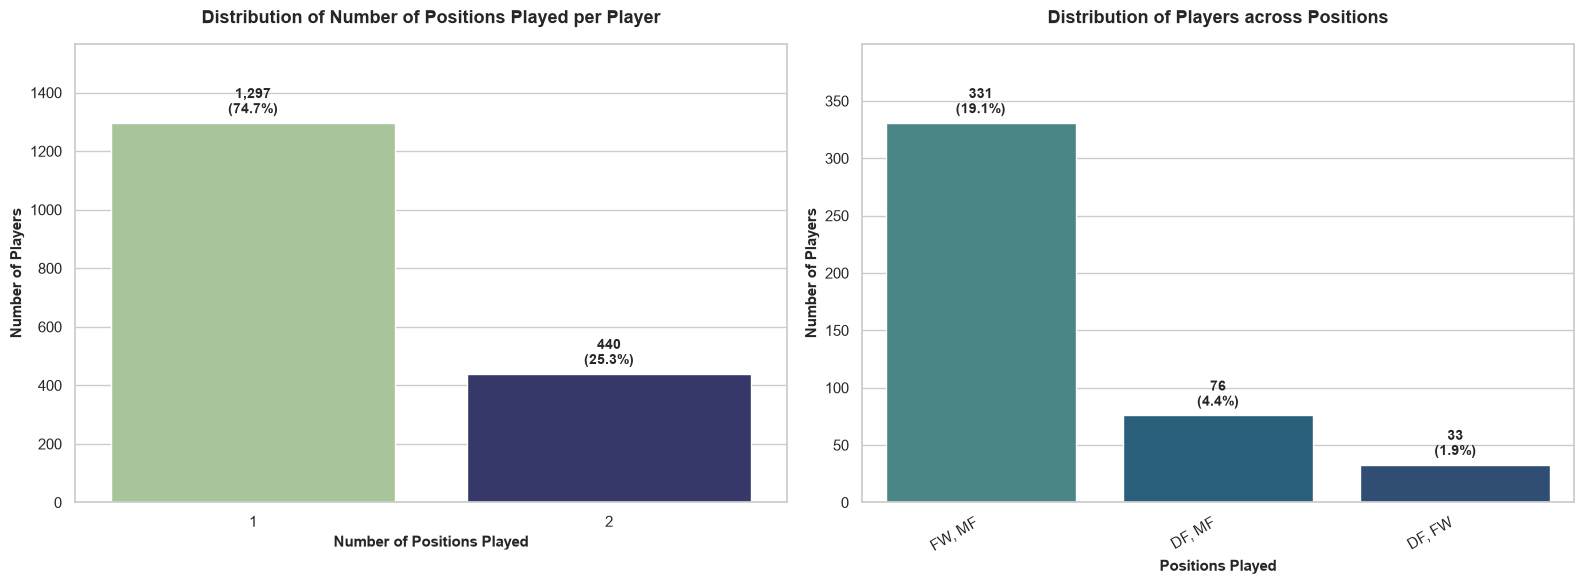

In [300]:
def clean_positions(pos_str):
  if not isinstance(pos_str, str) or pd.isna(pos_str):
      return ""
# Keep only alphabetical characters
  clean_str = "".join([c for c in pos_str if c.isalpha()])
# Chunk into 2-letter position codes (e.g., 'MFDFDF' -> ['MF', 'DF', 'DF'])
  chunks = [clean_str[i:i+2] for i in range(0, len(clean_str), 2) if len(clean_str[i:i+2]) == 2]
# Deduplicate and sort alphabetically
  unique_sorted = sorted(list(set(chunks)))
  return ", ".join(unique_sorted)

# Apply position cleanup to the dataset
aggregated_player_data['Pos'] = aggregated_player_data['Pos'].apply(clean_positions)

# Count the number of different positions played by each player (e.g., 'DF, MF' -> 2)
aggregated_player_data['Num_Pos'] = aggregated_player_data['Pos'].apply(lambda x: len(x.split(', ')) if x else 0)

multi_pos_players = aggregated_player_data[aggregated_player_data.Num_Pos > 1]

display(multi_pos_players.sample(5))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot total counts for each number of positions played
sns.countplot(
    data=aggregated_player_data,
    x="Num_Pos",
    hue="Num_Pos",
    palette="crest",
    ax=ax1,
)

# Remove the redundant legend generated by hue
if ax1.get_legend():
    ax1.get_legend().remove()

# Calculate total non-zero/valid entries for percentages
total_players = len(aggregated_player_data)

# Add count and percentage annotations above each bar
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total_players) * 100
        ax1.annotate(
            f"{int(height):,}\n({pct:.1f}%)",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

ax1.set_title(
    "Distribution of Number of Positions Played per Player",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax1.set_xlabel("Number of Positions Played", fontsize=11, fontweight="bold")
ax1.set_ylabel("Number of Players", fontsize=11, fontweight="bold")

# Expand top y-limit to prevent annotation cutoff
ylim1 = ax1.get_ylim()
ax1.set_ylim(ylim1[0], ylim1[1] * 1.15)

# Plot total counts for each value in 'Pos' column (sorted by count)
pos_order = multi_pos_players['Pos'].value_counts().index
sns.countplot(
    data=aggregated_player_data,
    x="Pos",
    hue="Pos",
    order=pos_order,
    palette="crest",
    ax=ax2,
)

# Remove the redundant legend generated by hue
if ax2.get_legend():
    ax2.get_legend().remove()

# Add count and percentage annotations above each bar for 'Pos' count plot
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total_players) * 100
        ax2.annotate(
            f"{int(height):,}\n({pct:.1f}%)",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

ax2.set_title(
    "Distribution of Players across Positions",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax2.set_xlabel("Positions Played", fontsize=11, fontweight="bold")
ax2.set_ylabel("Number of Players", fontsize=11, fontweight="bold")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")

# Expand top y-limit to prevent annotation cutoff
ylim2 = ax2.get_ylim()
ax2.set_ylim(ylim2[0], ylim2[1] * 1.15)

plt.tight_layout()
plt.show()

**Findings:**
There are far more Spanish and French players in Europe's top 5 leagues than other nationalities. Some way behind these are Germany, Italy, and England, before another significant drop off to other nationalities. Brazil, Argentina and Senegal are the only non-European nations in the Top 15.

La Liga and Serie A, 1 have the most players respresented, with Ligue 1 and the Premier League a little further behind. Bundesliga unsurprisingly has the least (due to only having 18 clubs in the league). Only a very small proportion of players have played in multiple leagues in the season, with the Premier League to Seria A being the most common switch.

42% of players are defenders, with 34% midfielders, and 24% forwards. 25.3% of players have also played a secondary position, with the vast majority (19.1% of all players) of these being players playing FW and MF

Italian, French, and Spanish clubs dominate the top squads by player count, with just two Premier League (Leicester and Watford), and no Bundesliga clubs. Paris Saint-Germain is the only elite-level club that stands out in the top 15.

In [301]:
# Perform a Chi-squared test to check for independence between the nations represented and each league
# Excluding the 5 Nations that the league's themselves are in

df_exploded = aggregated_player_data[
    ['player_identifier', 'Nation', 'Comp']
].copy()
df_exploded = df_exploded[
    ~df_exploded.Nation.isin(['ENG', 'GER', 'FRA', 'ESP', 'ITA'])
]

df_exploded['Nation'] = df_exploded['Nation'].str.split(', ')
df_exploded = df_exploded.explode('Nation')
df_exploded['Comp'] = df_exploded['Comp'].str.split(', ')
df_exploded = df_exploded.explode('Comp')

# Get Top 15 nations
top_15_nations = df_exploded['Nation'].value_counts().head(15).index
df_filtered = df_exploded[df_exploded['Nation'].isin(top_15_nations)].copy()
df_filtered = df_filtered.reset_index(drop=True)

# Sort for consistent ordering in plots
df_filtered = df_filtered.sort_values(by=['Nation', 'Comp'])

# 2. Chi-Squared Test of Independence
contingency_table = pd.crosstab(df_filtered['Nation'], df_filtered['Comp'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

# Calculate Pearson Residuals
residuals = (contingency_table - expected) / np.sqrt(expected)

# --- NEW: Build Annotation Matrix for Heatmap (Residual + Count) ---
annot_matrix = pd.DataFrame(
    '', index=residuals.index, columns=residuals.columns
)
for r in residuals.index:
  for c in residuals.columns:
    count = contingency_table.loc[r, c]
    res_val = residuals.loc[r, c]
    annot_matrix.loc[r, c] = f'{res_val:.2f}\n({count})'

print('--- Chi-Squared Test Results ---')
print(f'Chi-squared Statistic: {chi2:.4f}')
print(f'p-value: {p_val:.4e}')
print(f'Degrees of Freedom: {dof}')
print('\nSignificance:')
if p_val < 0.05:
  print(
      'Statistically Significant (p < 0.05). Nations are NOT distributed'
      ' proportionally across leagues.'
  )
else:
  print(
      'Not Statistically Significant (p >= 0.05). Nations are distributed'
      ' proportionally across leagues.'
  )

--- Chi-Squared Test Results ---
Chi-squared Statistic: 237.2285
p-value: 3.6476e-24
Degrees of Freedom: 56

Significance:
Statistically Significant (p < 0.05). Nations are NOT distributed proportionally across leagues.


/Users/Scott.Trowers/Documents/player_architect_analysis/.venv/lib/python3.14/site-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


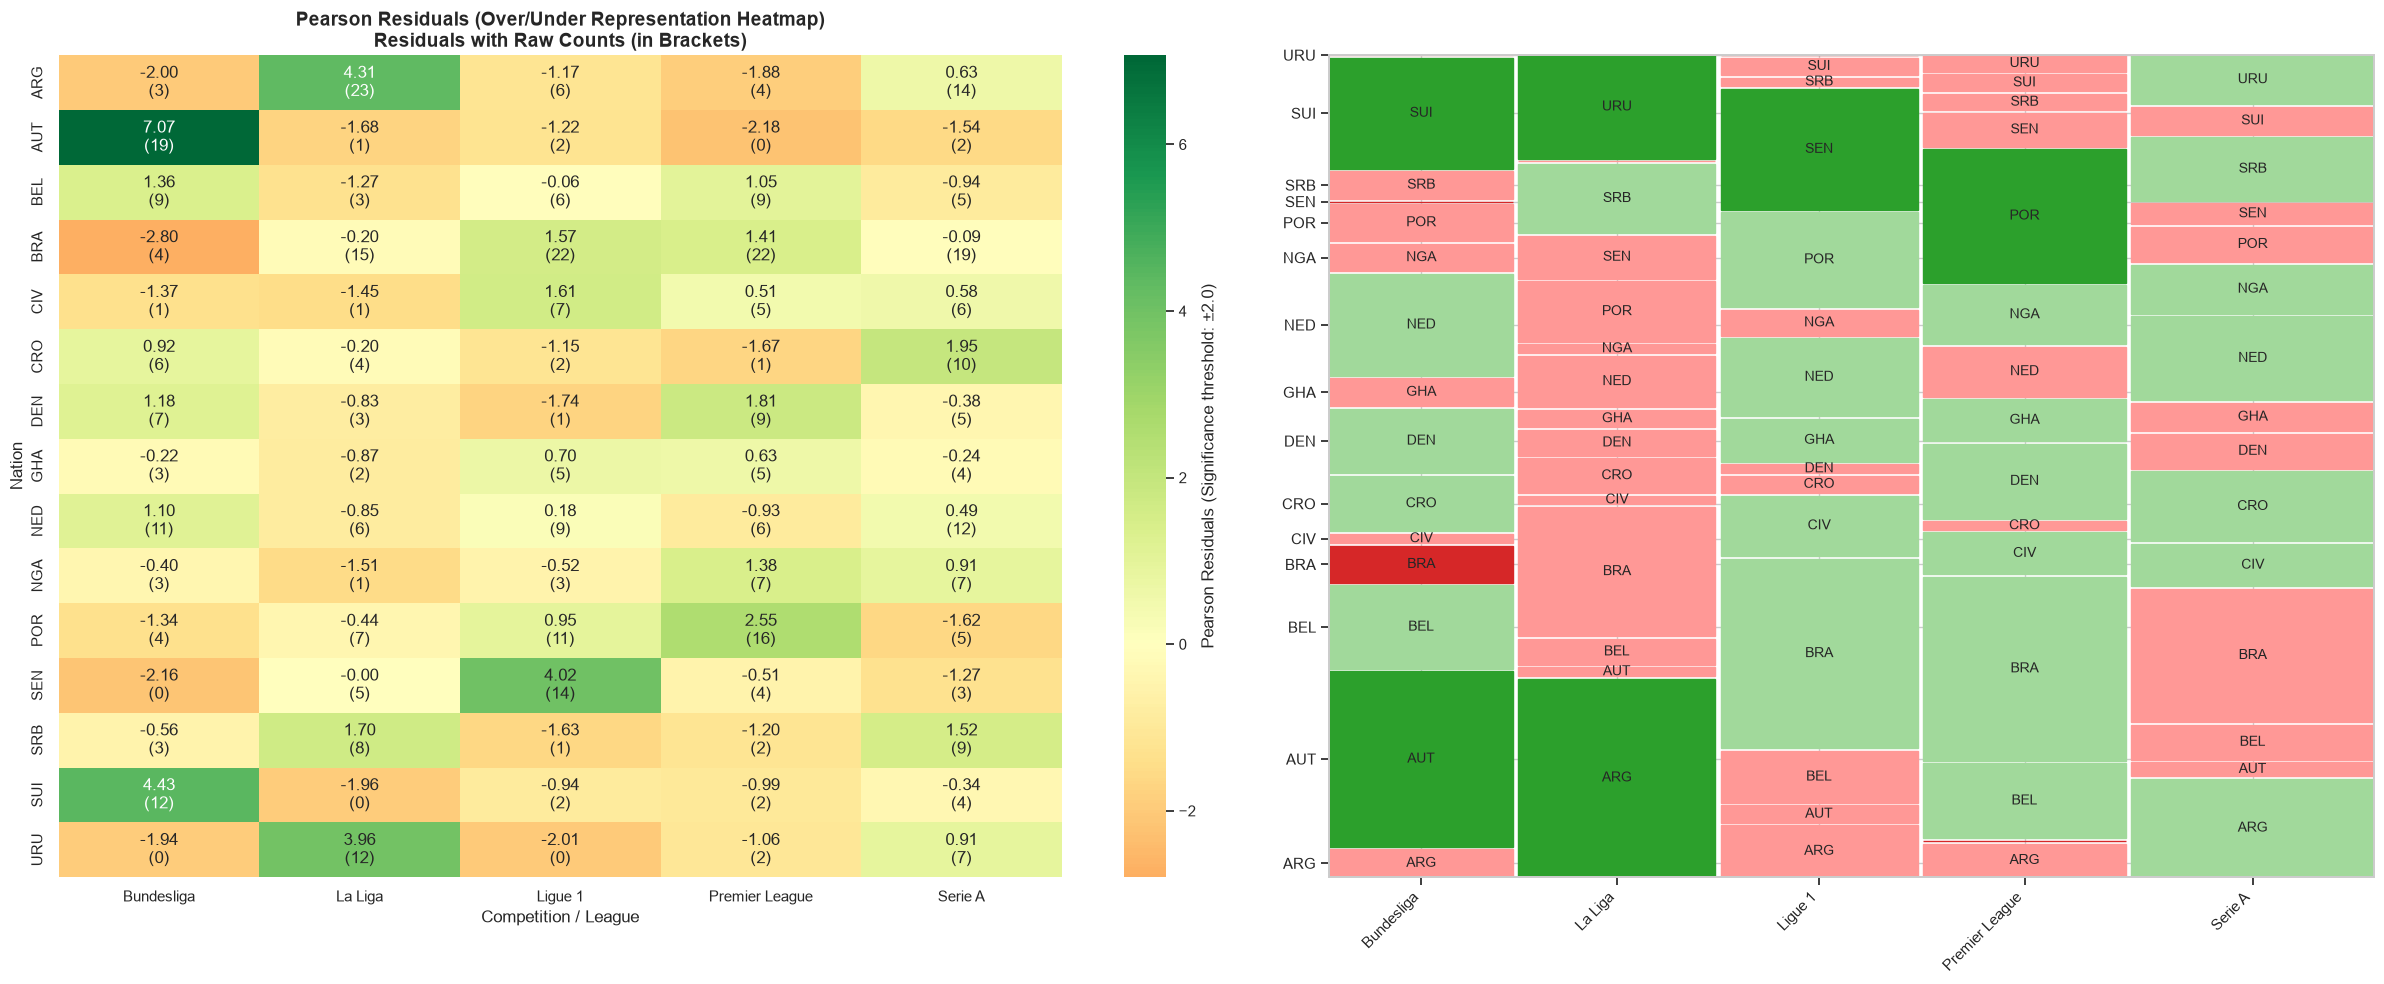

In [302]:
fig = plt.figure(figsize=(24, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

# Plot A: Residual Heatmap with Counts
ax_heatmap = fig.add_subplot(gs[0, 0])
sns.heatmap(
    residuals,
    annot=annot_matrix,  # Custom string matrix with count in brackets
    fmt='',  # Disable default numeric formatting
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Pearson Residuals (Significance threshold: ±2.0)'},
    ax=ax_heatmap,
)
ax_heatmap.set_title(
    'Pearson Residuals (Over/Under Representation Heatmap)\nResiduals with'
    ' Raw Counts (in Brackets)',
    fontsize=14,
    fontweight='bold',
)
ax_heatmap.set_xlabel('Competition / League')
ax_heatmap.set_ylabel('Nation')

# Plot B: Mosaic Plot (Flipped: Comp on x-axis, Nation on y-axis)
ax_mosaic = fig.add_subplot(gs[0, 1])


def cell_properties(key):
  # key is now a tuple: (Comp, Nation)
  comp, nation = key
  if nation in residuals.index and comp in residuals.columns:
    res = residuals.loc[nation, comp]
    if res > 2.0:
      color = (
          '#2ca02c'  # Statistically significant over-representation (Dark Green)
      )
    elif res < -2.0:
      color = (
          '#d62728'  # Statistically significant under-representation (Dark Red)
      )
    elif res > 0:
      color = (
          '#a1d99b'  # Mild/non-significant over-representation (Light Green)
      )
    else:
      color = '#ff9896'  # Mild/non-significant under-representation (Light Red)
  else:
    color = '#f0f0f0'
  return {'color': color, 'edgecolor': 'white'}


def cell_labelizer(key):
  # key is (Comp, Nation) -> return only the nation name
  comp, nation = key
  if nation in contingency_table.index and comp in contingency_table.columns:
    # Only label non-zero cells to avoid clutter
    if contingency_table.loc[nation, comp] > 0:
      return nation
  return ''


# Create Mosaic Plot using statsmodels with ['Comp', 'Nation'] order
mosaic(
    df_filtered,
    ['Comp', 'Nation'],
    properties=cell_properties,
    labelizer=cell_labelizer,  # Custom labelizer showing only nation names
    ax=ax_mosaic,
)

# Rotate labels on mosaic plot for legibility
plt.setp(ax_mosaic.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Findings:**

Even excluding the nations that are home to the top 5 leagues, the nations represented are not independent of the league.
- In the Bundesliga, Austrian and Swiss Players in particular are over-represented vs the other Top 5 leagues, while South Americans (from Argentina, Brazil, and Uruguay) are the most under-represented.
- Conversely, Argentineans and Uruguayans are significantly over-represented in La Liga
- Senegalese and Ivorians are the over-represented in Ligue 1
- The Premier League and Serie A has fewer extremes. Portuguese, Danish, and Brazilian players are over-represented in the former, with Argentineans, Danes and Croats under-represented in the former. In Serie A, Polish and Croatian players are over-represented.

### Qualitative EDA

The majority of metrics are raw counts, which can be skewed simply by playing time (e.g., a player who plays twice as many minutes may have more total passes than a player who has had limited playtime but makes far more passes per game). These counts can therefore be normalised by calculating the 'per 90 min' equivalents. Ratios, Percentages, and already-calculated-averages (e.g goals-per-shot) do not require further normalisation.

#### Age

`Age` and `Born` show essentially the same data, so the latter will be dropped.

In [307]:
#

aggregated_player_data.drop('Born', axis=1, inplace=True)



#### Normalising data per 90 minutes played

In [303]:
columns_to_normalise = [
       'Goals', 'Shots', 'SoT', 'ShoFK', 'ShoPK', 'PKatt', 'PasTotCmp', 'PasTotAtt',
       'PasTotDist', 'PasTotPrgDist', 'PasShoCmp', 'PasShoAtt', 'PasMedCmp', 'PasMedAtt',
       'PasLonCmp', 'PasLonAtt', 'Assists', 'PasAss', 'Pas3rd', 'PPA', 'CrsPA',
       'PasProg', 'PasAtt', 'PasLive', 'PasDead', 'PasFK', 'TB', 'PasPress', 'Sw',
       'PasCrs', 'CK', 'CkIn', 'CkOut', 'CkStr', 'PasGround', 'PasLow', 'PasHigh',
       'PaswLeft', 'PaswRight', 'PaswHead', 'TI', 'PaswOther', 'PasCmp', 'PasOff',
       'PasOut', 'PasInt', 'PasBlocks', 'SCA', 'ScaPassLive', 'ScaPassDead', 'ScaDrib',
       'ScaSh', 'ScaFld', 'ScaDef', 'GCA', 'GcaPassLive', 'GcaPassDead', 'GcaDrib',
       'GcaSh', 'GcaFld', 'GcaDef', 'Tkl', 'TklWon', 'TklDef3rd', 'TklMid3rd',
       'TklAtt3rd', 'TklDri', 'TklDriAtt', 'TklDriPast', 'Press', 'PresSucc',
       'PresDef3rd', 'PresMid3rd', 'PresAtt3rd', 'Blocks', 'BlkSh', 'BlkShSv',
       'BlkPass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Touches', 'TouDefPen', 'TouDef3rd',
       'TouMid3rd', 'TouAtt3rd', 'TouAttPen', 'TouLive', 'DriSucc', 'DriAtt',
       'DriPast', 'DriMegs', 'Carries', 'CarTotDist', 'CarPrgDist', 'CarProg',
       'Car3rd', 'CPA', 'CarMis', 'CarDis', 'RecTarg', 'Rec', 'RecProg', 'CrdY',
       'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'TklW', 'PKwon', 'PKcon',
       'OG', 'Recov', 'AerWon', 'AerLost'
   ]

player_data_p90 = aggregated_player_data.copy()

for raw_col_name in columns_to_normalise:
    new_col_name = f"{raw_col_name}_p90"

    player_data_p90[new_col_name] = player_data_p90[raw_col_name] / player_data_p90['90s']

    player_data_p90.drop(raw_col_name, axis=1, inplace=True)

player_data_p90 = player_data_p90.copy()

player_data_p90.describe()

/var/folders/z2/nnyy1mcn66g48lv04812439r0000gp/T/ipykernel_36018/4082477770.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_data_p90[new_col_name] = player_data_p90[raw_col_name] / player_data_p90['90s']


,Born,Age,MP,Starts,Min,Premier League_pct_mins,Ligue 1_pct_mins,Bundesliga_pct_mins,Serie A_pct_mins,La Liga_pct_mins,...,Fld_p90,Off_p90,Crs_p90,TklW_p90,PKwon_p90,PKcon_p90,OG_p90,Recov_p90,AerWon_p90,AerLost_p90
count,1737.000000,1737.000000,1737.000000,1737.000000,1737.00000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,...,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000
mean,1994.748993,26.742660,26.120322,20.085780,1780.84456,0.201532,0.202855,0.171521,0.211994,0.212098,...,0.082607,0.011863,0.072180,0.069464,0.000672,0.000910,0.000239,0.484113,0.106283,0.113942
std,4.112933,4.120448,7.126404,8.609093,718.69894,0.400204,0.401550,0.376696,0.407982,0.408386,...,0.070085,0.021387,0.080685,0.052768,0.002353,0.002492,0.001250,0.284064,0.097668,0.113297
min,1981.000000,17.000000,7.000000,2.000000,603.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.083612,0.000000,0.002736
25%,1992.000000,24.000000,21.000000,13.000000,1149.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.036973,0.000000,0.014787,0.034173,0.000000,0.000000,0.000000,0.289896,0.042165,0.048934
50%,1995.000000,26.000000,27.000000,20.000000,1755.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.063606,0.003497,0.047114,0.053948,0.000000,0.000000,0.000000,0.403011,0.079209,0.080127
75%,1998.000000,30.000000,32.000000,27.000000,2345.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.104128,0.013628,0.102515,0.087705,0.000000,0.000000,0.000000,0.607961,0.133752,0.135922
max,2004.000000,40.000000,38.000000,38.000000,3420.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.578112,0.229339,0.603421,0.365538,0.034261,0.022351,0.019062,1.981295,0.788824,1.377638


In [304]:
minimum_mins = 600

display(player_data_p90[player_data_p90.Goals_p90 > 10])

under_600m_player_count = (aggregated_player_data.Min < minimum_mins).sum()
under_600m_pct = under_600m_player_count / len(aggregated_player_data.Min)
print(f"{under_600m_player_count} ({100 * under_600m_pct:.2f}%) players with less than {minimum_mins} minutes")

,player_identifier,Player,Nation,Born,Age,Pos,Squad,Comp,MP,Starts,...,Fld_p90,Off_p90,Crs_p90,TklW_p90,PKwon_p90,PKcon_p90,OG_p90,Recov_p90,AerWon_p90,AerLost_p90


0 (0.00%) players with less than 600 minutes


Now stats are all normalised as per-90-minutes, averages, or ratio metrics, comparisons between players are more robust. However, p90 stats can still be skewed by players with a very low number of minutes. For example, Pablo Sarabia played just 22 minutes, but as he scored a goal, his Goals_p90 statistic is very high (>20). A requirment of having played 600 minutes will therefore be introduced.


In [305]:
player_data_p90 = player_data_p90[player_data_p90.Min >= minimum_mins].copy()

The remaining features can now be explored.

There are 141 metrics in the dataset; far too many to explore one by one, or all at once. However, these metrics can broadly be categorised (see the data-dictionary.md for these categories).

In [306]:
# Column names by category

matches_played_cols = ['MP', 'Starts', 'Min', '90s']
finishing_cols = ['SoT%', 'G/Sh', 'G/SoT', 'ShoDist', 'Goals_p90', 'Shots_p90', 'SoT_p90']
set_pieces_cols = ['ShoFK_p90', 'ShoPK_p90', 'PKatt_p90', 'PasDead_p90', 'PasFK_p90', 'CK_p90', 'CkIn_p90', 'CkOut_p90', 'CkStr_p90', 'TI_p90', 'ScaPassDead_p90', 'GcaPassDead_p90']
chance_creation_cols = ['Assists_p90', 'PasAss_p90', 'SCA_p90', 'ScaPassLive_p90', 'ScaDrib_p90', 'ScaSh_p90', 'ScaFld_p90', 'ScaDef_p90', 'GCA_p90', 'GcaPassLive_p90', 'GcaDrib_p90', 'GcaSh_p90', 'GcaFld_p90', 'GcaDef_p90', 'PKwon_p90']
passing_cols = ['PasTotCmp%', 'PasShoCmp%', 'PasMedCmp%', 'PasLonCmp%', 'PasTotCmp_p90', 'PasTotAtt_p90', 'PasTotDist_p90', 'PasTotPrgDist_p90', 'PasShoCmp_p90', 'PasShoAtt_p90', 'PasMedCmp_p90', 'PasMedAtt_p90', 'PasLonCmp_p90', 'PasLonAtt_p90',
'Pas3rd_p90', 'PPA_p90', 'CrsPA_p90', 'PasProg_p90', 'PasAtt_p90', 'PasLive_p90', 'TB_p90', 'PasPress_p90', 'Sw_p90', 'PasCrs_p90', 'PasGround_p90', 'PasLow_p90', 'PasHigh_p90', 'PaswLeft_p90', 'PaswRight_p90', 'PaswHead_p90', 'PaswOther_p90', 'PasCmp_p90',
'PasOut_p90', 'PasInt_p90', 'PasBlocks_p90', 'RecProg_p90', 'Crs_p90']
positioning_cols = ['PasOff_p90', 'Off_p90']
defensive_plays_cols = ['TklDri%', 'Tkl_p90', 'TklWon_p90', 'TklDef3rd_p90', 'TklMid3rd_p90', 'TklAtt3rd_p90', 'TklDri_p90', 'TklDriAtt_p90', 'TklDriPast_p90', 'Blocks_p90', 'BlkSh_p90', 'BlkShSv_p90', 'BlkPass_p90', 'Int_p90', 'Tkl+Int_p90', 'Clr_p90',
'Err_p90', 'TklW_p90', 'PKcon_p90', 'OG_p90', 'Recov_p90']
pressures_cols = ['Press%', 'Press_p90', 'PresSucc_p90', 'PresDef3rd_p90', 'PresMid3rd_p90', 'PresAtt3rd_p90']
involvement_cols = ['Rec%', 'Touches_p90', 'TouDefPen_p90', 'TouDef3rd_p90', 'TouMid3rd_p90', 'TouAtt3rd_p90', 'TouAttPen_p90', 'TouLive_p90', 'RecTarg_p90', 'Rec_p90']
dribbling_cols = ['DriSucc%', 'DriSucc_p90', 'DriAtt_p90', 'DriPast_p90', 'DriMegs_p90', 'Carries_p90', 'CarTotDist_p90', 'CarPrgDist_p90', 'CarProg_p90', 'Car3rd_p90', 'CPA_p90', 'CarMis_p90', 'CarDis_p90', 'Fld_p90']
discipline_cols = ['CrdY_p90', 'CrdR_p90', '2CrdY_p90', 'Fls_p90']
aerial_ability_cols = ['AerWon%', 'AerWon_p90', 'AerLost_p90']


### Reusable Metric Group Explorer

Repeating the same five-part exploration by hand for every remaining category does not scale. `explore_column_group` standardises it for any list of columns: descriptive statistics (with skew and kurtosis), a histogram/KDE + boxplot grid, a correlation matrix, a `Primary_Pos`-coloured scatterplot matrix, a scaled parallel coordinates plot, and a grid of bar charts showing each column's mean by `Primary_Pos`.

### Outlier Exploration Helper

`explore_outliers` highlights a specific set of players (by `player_identifier`) against the rest of the (optionally position-filtered) dataset: a parallel coordinates plot, a full scatterplot matrix, and a radar grid with one panel per highlighted player plus a dataset-average panel.

### Matches Played Exploration

The 'MP', 'Starts', 'Min', and '90s' columns all relate to the amount of football played.

- Print summary statistics (including skew and kurtosis)
- Histogram with density curve, and an integrated box plot
- Correlation heatmap of the columns
- scatterplot of MP vs Starts, coloured by Min

Matches Played Column Statistics:


,MP,Starts,Min,90s,avg_minutes_per_match
count,1737.000000,1737.000000,1737.00000,1737.000000,1737.000000
mean,26.120322,20.085780,1780.84456,19.787162,67.119285
std,7.126404,8.609093,718.69894,7.985544,15.591330
min,7.000000,2.000000,603.00000,6.700000,23.357143
25%,21.000000,13.000000,1149.00000,12.766667,55.724138
50%,27.000000,20.000000,1755.00000,19.500000,69.428571
75%,32.000000,27.000000,2345.00000,26.055556,80.366667
max,38.000000,38.000000,3420.00000,38.000000,90.000000



Skewness and Kurtosis:
MP                     - Skewness: -0.45, Kurtosis: -0.72
Starts                 - Skewness: 0.10, Kurtosis: -1.08
Min                    - Skewness: 0.18, Kurtosis: -1.03
90s                    - Skewness: 0.18, Kurtosis: -1.03
avg_minutes_per_match  - Skewness: -0.49, Kurtosis: -0.67


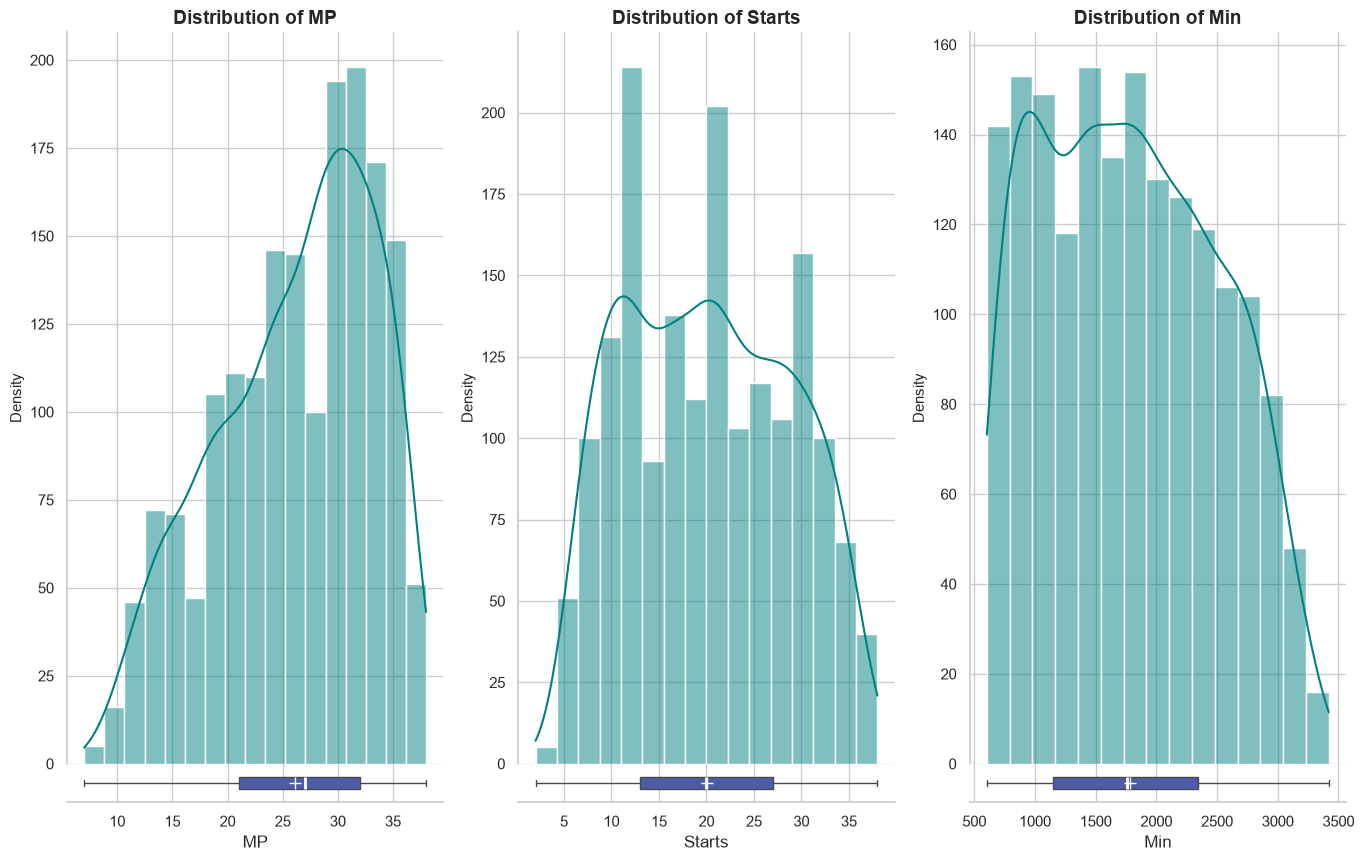

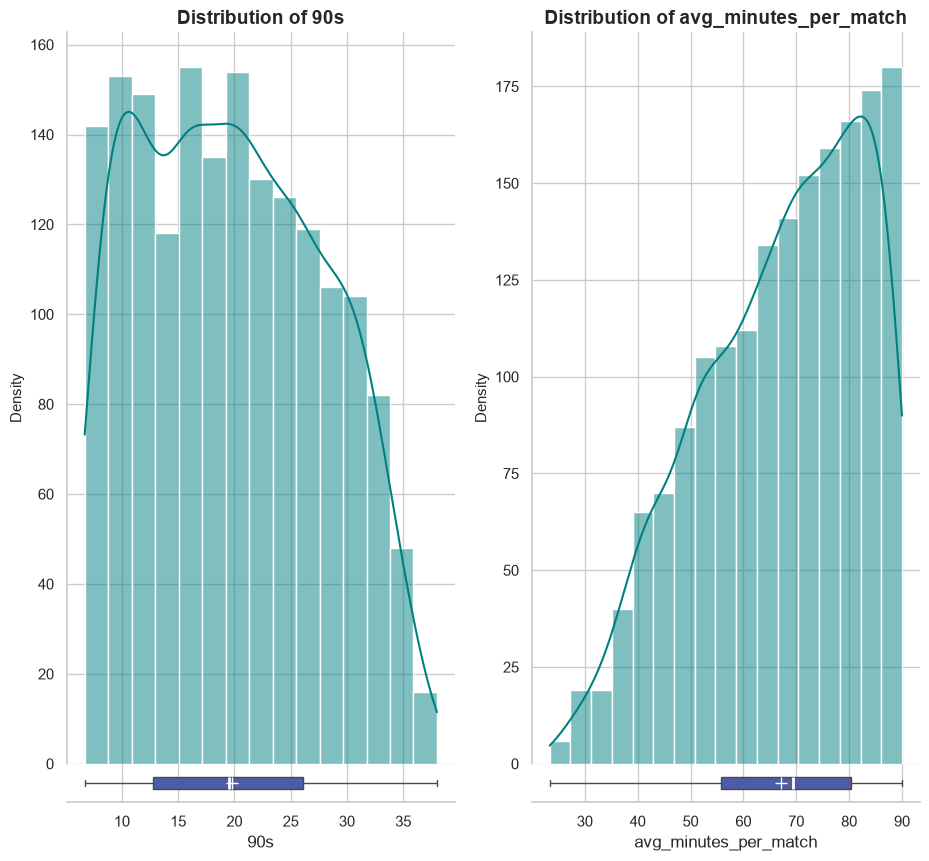

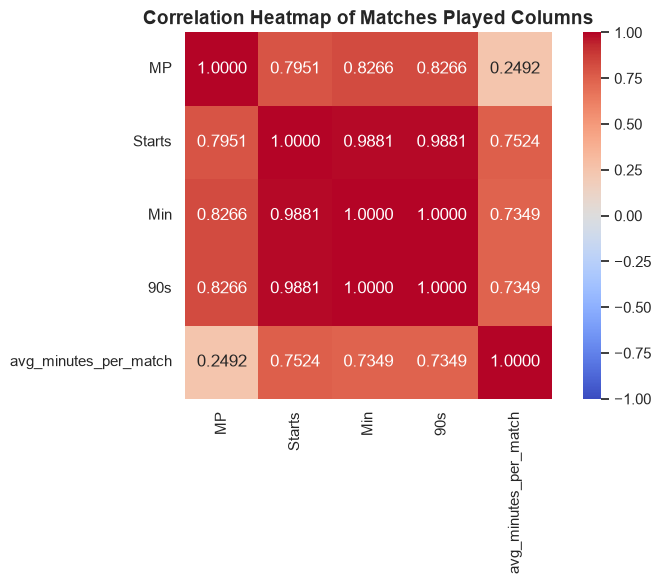

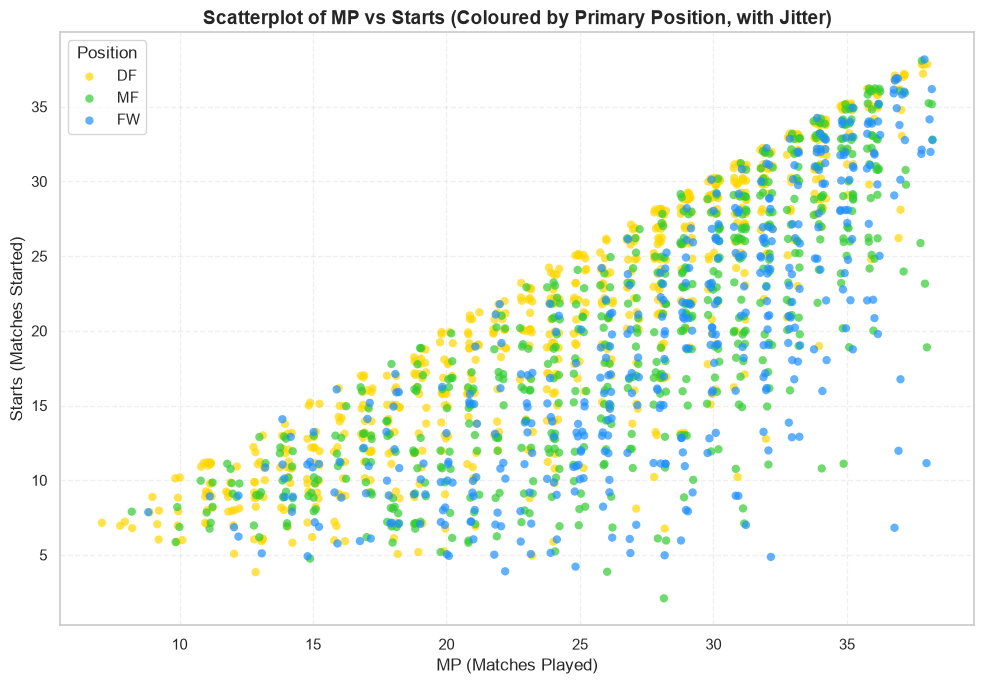

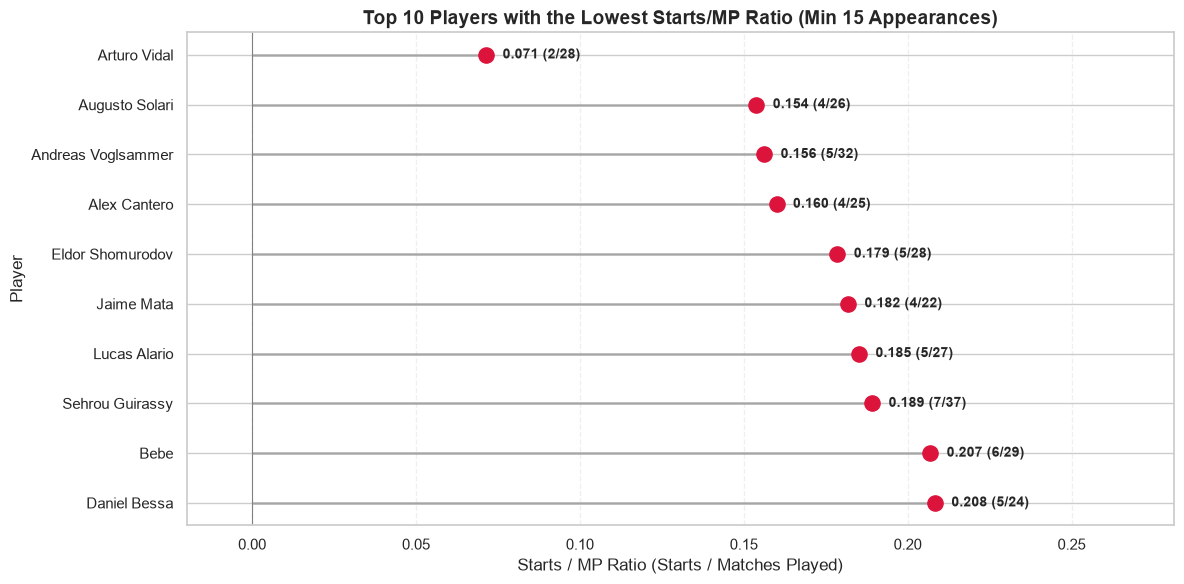

In [308]:
# Create an avg_minutes_per_match column
player_data_p90['avg_minutes_per_match'] = player_data_p90.Min / player_data_p90.MP

# Explicitly define the base columns and append to avoid duplicate appends when running multiple times
matches_played_cols = ['MP', 'Starts', 'Min', '90s', 'avg_minutes_per_match']

# 1. Summary Statistics for Matches Played
print("Matches Played Column Statistics:")
display(player_data_p90[matches_played_cols].describe())

# Check skewness and kurtosis
print("\nSkewness and Kurtosis:")
for col in matches_played_cols:
    print(f"{col:22} - Skewness: {player_data_p90[col].skew():.2f}, Kurtosis: {player_data_p90[col].kurt():.2f}")


# 1. Individual Distributions: Histogram with density curve on top, Box plot directly underneath (floating, shared X-axis)
# Split matches played columns into chunks of max 3 per row (row of 3 and row of 2)
chunks = [matches_played_cols[i:i + 3] for i in range(0, len(matches_played_cols), 3)]

for chunk_idx, chunk in enumerate(chunks):
    n_cols = len(chunk)
    # Scale figure width to keep individual subplot aspect ratios consistent
    fig_width = n_cols * 5.5
    fig, axes = plt.subplots(2, n_cols, figsize=(fig_width, 10), sharex='col', gridspec_kw={'height_ratios': (0.95, 0.05)})
    
    # Ensure axes is treated as 2D array of shape (2, n_cols)
    for i, col in enumerate(chunk):
        # Top Row: Histogram with KDE
        ax_hist = axes[0, i]
        sns.histplot(data=player_data_p90, x=col, kde=True, color='teal', ax=ax_hist)

        ax_hist.set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
        ax_hist.set_ylabel('Density', fontsize=11)
        ax_hist.tick_params(labelbottom=False)
        sns.despine(ax=ax_hist, top=True, right=True, bottom=True)
        
        # Bottom Row: Box plot directly underneath sharing the same X-axis
        ax_box = axes[1, i]
        sns.boxplot(
            data=player_data_p90, 
            x=col, 
            color='#3F51B5', 
            width=0.3, 
            ax=ax_box, 
            showmeans=True,
            meanprops={"marker": "+", "markeredgecolor": "white", "markerfacecolor": "white", "markersize": 8},
            medianprops={"color": "white", "linewidth": 2},
            fliersize=2
        )
        ax_box.set_xlabel(col, fontsize=12)
        ax_box.yaxis.set_visible(False)  # Hide the y-axis entirely for the box plot subplot
        sns.despine(ax=ax_box, left=True, top=True, right=True, bottom=False)

    # Adjust subplot parameters to stack the plots with zero vertical spacing
    fig.subplots_adjust(hspace=0.0)
    plt.show()

# 2. Correlation heatmap of the matches_played_cols
plt.figure(figsize=(8, 6))
corr_matrix = player_data_p90[matches_played_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.4f', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap of Matches Played Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Scatterplot of MP vs Starts, coloured by Primary_Pos (with Jitter and Custom Palette)
plt.figure(figsize=(10, 7))
import numpy as np

# Adding small random noise (jitter) to x and y coordinates to prevent points from completely overlapping
x_jitter = player_data_p90['MP'] + np.random.uniform(-0.25, 0.25, size=len(player_data_p90))
y_jitter = player_data_p90['Starts'] + np.random.uniform(-0.25, 0.25, size=len(player_data_p90))

# Define position color palette mapping
pos_palette_map = {
    "DF": "gold",
    "MF": "limegreen",
    "FW": "dodgerblue",
    "GK": "darkorange",
    "FW, MF": "lightseagreen",
    "DF, FW": "goldenrod",
    "DF, MF": "yellowgreen",
    "DF, MF, FW": "darkviolet",
    "GK, MF": "red"
}

# Plot each position group separately to map custom colors and build the legend
for pos, color in pos_palette_map.items():
    mask = player_data_p90['Primary_Pos'] == pos
    if mask.sum() > 0:
        plt.scatter(
            x=x_jitter[mask],
            y=y_jitter[mask],
            color=color,
            label=pos,
            alpha=0.7,
            edgecolors='none'
        )

plt.title('Scatterplot of MP vs Starts (Coloured by Primary Position, with Jitter)', fontsize=14, fontweight='bold')
plt.xlabel('MP (Matches Played)', fontsize=12)
plt.ylabel('Starts (Matches Started)', fontsize=12)
plt.legend(title='Position', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Horizontal Lollipop Chart: Top 10 players with the lowest Starts/MP ratio (Super-subs)
# To avoid fringe players with only 1 or 2 sub appearances, we filter for a minimum of 10 matches played (MP)
active_players = player_data_p90[player_data_p90['MP'] >= 15].copy()
active_players['Starts_MP_Ratio'] = active_players['Starts'] / active_players['MP']

# Get the top 10 players with the lowest ratio, sorted for plotting (lowest at the bottom so it reads lowest to highest upwards)
top_10_subs = active_players.sort_values(by='Starts_MP_Ratio', ascending=True).head(10)
top_10_subs = top_10_subs.sort_values(by='Starts_MP_Ratio', ascending=False)

plt.figure(figsize=(12, 6))

# Draw vertical reference line at 0
plt.axvline(x=0, color='grey', linestyle='-', linewidth=0.8)

# Draw horizontal grey lines (sticks)
plt.hlines(y=top_10_subs['Player'], xmin=0, xmax=top_10_subs['Starts_MP_Ratio'], color='grey', alpha=0.5, linewidth=2)

# Draw crimson circles (lollipops)
plt.scatter(x=top_10_subs['Starts_MP_Ratio'], y=top_10_subs['Player'], color='crimson', zorder=3, s=120)

# Annotate each lollipop with its exact ratio value for absolute clarity
for index, row in top_10_subs.iterrows():
    plt.text(
        x=row['Starts_MP_Ratio'] + 0.005,
        y=row['Player'],
        s=f"{row['Starts_MP_Ratio']:.3f} ({int(row['Starts'])}/{int(row['MP'])})",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Top 10 Players with the Lowest Starts/MP Ratio (Min 15 Appearances)', fontsize=14, fontweight='bold')
plt.xlabel('Starts / MP Ratio (Starts / Matches Played)', fontsize=12)
plt.ylabel('Player', fontsize=12)
plt.xlim(-0.02, max(top_10_subs['Starts_MP_Ratio']) * 1.35)
plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Finishing Metrics Exploration

We will now explore `finishing_cols` (`['SoT%', 'G/Sh', 'G/SoT', 'ShoDist', 'Goals_p90', 'Shots_p90', 'SoT_p90']`). We will analyze their individual distributions and examine how they interact (e.g. how shot distance and shot volume relate to goals scored).

In [ ]:
# Define the finishing columns explicitly to avoid any active session variable pollution
finishing_cols = ['SoT%', 'G/Sh', 'G/SoT', 'ShoDist', 'Goals_p90', 'Shots_p90', 'SoT_p90']

# 1. Summary Statistics for Finishing (including Skewness and Kurtosis)
print("Finishing Column Statistics:")
display(player_data_p90[finishing_cols].describe())

print("\nSkewness and Kurtosis for Finishing Columns:")
for col in finishing_cols:
    print(f"{col:12} - Skewness: {player_data_p90[col].skew():.4f}, Kurtosis: {player_data_p90[col].kurt():.4f}")

# 2. Individual Distributions: Histogram with density curve on top, Box plot directly underneath (floating, shared X-axis)
# To keep the layout balanced and clean, we split the 7 columns into rows of max 4 columns
chunks = [finishing_cols[i:i + 4] for i in range(0, len(finishing_cols), 4)]

for chunk_idx, chunk in enumerate(chunks):
    n_cols = len(chunk)
    # Scale figure width to keep individual subplot aspect ratios consistent
    fig_width = n_cols * 5.5
    fig, axes = plt.subplots(2, n_cols, figsize=(fig_width, 10), sharex='col', gridspec_kw={'height_ratios': (0.85, 0.15)})
    
    # If n_cols == 1, axes is 1D; but here we always have 4 or 3 columns, so axes is 2D of shape (2, n_cols)
    for i, col in enumerate(chunk):
        # Top Row: Histogram with KDE
        ax_hist = axes[0, i]
        sns.histplot(data=player_data_p90, x=col, kde=True, color='teal', ax=ax_hist)

        ax_hist.set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
        ax_hist.set_ylabel('Density', fontsize=11)
        ax_hist.tick_params(labelbottom=False)
        sns.despine(ax=ax_hist, top=True, right=True, bottom=True)
        
        # Bottom Row: Box plot directly underneath sharing the same X-axis
        ax_box = axes[1, i]
        sns.boxplot(
            data=player_data_p90, 
            x=col, 
            color='#3F51B5', 
            width=0.3, 
            ax=ax_box, 
            showmeans=True,
            meanprops={"marker": "+", "markeredgecolor": "white", "markerfacecolor": "white", "markersize": 8},
            medianprops={"color": "white", "linewidth": 2},
            fliersize=2
        )
        ax_box.set_xlabel(col, fontsize=12)
        ax_box.yaxis.set_visible(False)  # Hide the y-axis entirely for the box plot subplot
        sns.despine(ax=ax_box, left=True, top=True, right=True, bottom=False)

    # Adjust subplot parameters to stack the plots with zero vertical spacing
    fig.subplots_adjust(hspace=0.0)
    plt.show()

# 3. Correlation heatmap of the finishing columns
plt.figure(figsize=(10, 8))
corr_finish = player_data_p90[finishing_cols].corr()
sns.heatmap(corr_finish, annot=True, cmap='coolwarm', fmt='.4f', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap of Finishing Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Pairwise Relationship Matrix (Categorical Grouping)

To replicate R's `ggpairs` functionality, we use Seaborn's `PairGrid` to construct a pairwise relationship matrix of our finishing metrics, color-grouped by player position (`Pos`). This visualization includes:
- **Diagonal:** Kernel Density Estimate (KDE) curves representing the distribution of each metric per position.
- **Lower Triangle:** Position-colored scatter plots showing individual observations.
- **Upper Triangle:** Overlaid Pearson correlation coefficients (`r`) for each metric pair.

In [ ]:
from pandas.plotting import parallel_coordinates

df = player_data_p90[finishing_cols + ['Primary_Pos']]
# fixed colour order so 'Primary_Pos' groups map to the same colour in every plot
POS_COLORS = {
    pos: hex_
    for pos, hex_ in zip(sorted(df['Primary_Pos'].unique()), ['#2a78d6', '#eb6834', '#1baf7a', '#eda100'])
}

numeric_cols = df.select_dtypes(include='number').columns.tolist()

# --- parallel coordinates (min-max scaled so every axis is comparable) ---
scaled = df[numeric_cols].apply(lambda s: (s - s.min()) / (s.max() - s.min()))
scaled['Primary_Pos'] = df['Primary_Pos'].values

fig, ax = plt.subplots(figsize=(12, 6))
parallel_coordinates(scaled, 'Primary_Pos', color=[POS_COLORS[p] for p in sorted(POS_COLORS)], ax=ax, alpha=0.6)
ax.set_title('Parallel coordinates (scaled) by Primary_Pos')
ax.legend(title='Primary_Pos', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 2x2 radar grid: mean of each numeric column per Primary_Pos group ---
group_means = df.groupby('Primary_Pos')[numeric_cols].mean()

angles = np.linspace(0, 2 * np.pi, len(numeric_cols), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(2, 2, figsize=(10, 10), subplot_kw=dict(polar=True))

for ax, pos in zip(axes.flat, group_means.index):
    values = group_means.loc[pos].tolist()
    values += values[:1]

    ax.plot(angles, values, color=POS_COLORS[pos], linewidth=2)
    ax.fill(angles, values, color=POS_COLORS[pos], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(numeric_cols, fontsize=8)
    ax.set_title(pos, color=POS_COLORS[pos], fontsize=12, pad=15)

plt.tight_layout()
plt.show()

In [ ]:
x = np.arange(len(numeric_cols))
n_groups = len(group_means.index)
bar_width = 0.8 / n_groups

fig, ax = plt.subplots(figsize=(12, 6))

for i, pos in enumerate(group_means.index):
    offset = (i - (n_groups - 1) / 2) * bar_width
    ax.bar(x + offset, group_means.loc[pos], width=bar_width,
           label=pos, color=POS_COLORS[pos])

ax.set_xticks(x)
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_title('Mean by column, grouped by Primary_Pos')
ax.legend(title='Primary_Pos')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4), sharex=False)

for ax, col in zip(axes, numeric_cols):
    ax.bar(group_means.index, group_means[col], color=[POS_COLORS[p] for p in group_means.index])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# radar grid with per-axis scaling: each spoke normalized independently,
# but labeled with its own raw min/max so no axis is obscured by another's range

col_min = group_means.min()
col_max = group_means.max()
col_range = (col_max - col_min).replace(0, 1)  # guard against constant columns

normalized = (group_means - col_min) / col_range

angles = np.linspace(0, 2 * np.pi, len(numeric_cols), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))

for ax, pos in zip(axes.flat, group_means.index):
    values = normalized.loc[pos].tolist()
    values += values[:1]
    raw_values = group_means.loc[pos].tolist()

    ax.plot(angles, values, color=POS_COLORS[pos], linewidth=2)
    ax.fill(angles, values, color=POS_COLORS[pos], alpha=0.25)

    ax.set_ylim(0, 1)
    ax.set_yticklabels([])  # shared radial ticks would be meaningless here
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(numeric_cols, fontsize=8)
    ax.set_title(pos, color=POS_COLORS[pos], fontsize=12, pad=20)

    # per-axis min/max, in raw units, placed at the spoke's centre and rim
    for angle, col in zip(angles[:-1], numeric_cols):
        ax.text(angle, -0.08, f'{col_min[col]:.2f}', fontsize=8, ha='center', va='center', color='#898781')
        ax.text(angle, 1.08, f'{col_max[col]:.2f}', fontsize=8, ha='center', va='center', color='#898781')

    # direct label on each raw value so the actual number is always visible
    for angle, val, raw in zip(angles[:-1], values[:-1], raw_values):
        ax.text(angle, val + 0.05, f'{raw:.2f}', fontsize=7, ha='center', va='center', color=POS_COLORS[pos])

plt.tight_layout()
plt.show()

### Set Pieces Exploration

Applying `explore_column_group` to `set_pieces_cols` as the next metric category.

In [ ]:
explore_column_group(player_data_p90, set_pieces_cols)


### Finishing Metrics Exploration (via explore_column_group)

Re-running the finishing metrics through the reusable explorer, for consistency with the other metric categories.

In [ ]:
explore_column_group(player_data_p90, finishing_cols)


### Outlier Exploration - Top Finishers (via explore_outliers)

Highlighting the top 5 players by `Goals_p90` against forwards and midfielders, using `finishing_cols`.

In [ ]:
top_finishers = player_data_p90.nlargest(5, 'Goals_p90')['player_identifier'].tolist()
explore_outliers(player_data_p90, top_finishers, finishing_cols, primary_pos=['FW', 'MF'])


### Dimensionality Reduction - PCA & Factor Analysis

`explore_dimensionality_reduction` standardises the input columns, uses a scree plot (elbow heuristic on the eigenvalues) to choose the number of dimensions `k`, then fits both PCA and Factor Analysis with that `k`. Player scores (coloured by `Primary_Pos`) are plotted against the first two dimensions, alongside the original features' loading vectors.

### Finishing Metrics - PCA & Factor Analysis (via explore_dimensionality_reduction)

In [ ]:
explore_dimensionality_reduction(player_data_p90, finishing_cols)
